In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# Cargar el dataset
data = pd.read_csv('../data/titanic_ia.csv', header="infer")
# Mostrar las primeras filas del dataset
data.head()

,hombre,pclass_2,pclass_3,acompanantes_1,acompanantes_2,acompanantes_3,acompanantes_4,acompanantes_5,acompanantes_6,acompanantes_7,acompanantes_10,edad_Adolescente,edad_Adulto Joven,edad_Adulto,edad_Anciano,survived
0,True,False,True,True,False,False,False,False,False,False,False,False,True,False,False,0
1,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,1
2,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,1
3,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,1
4,True,False,True,False,False,False,False,False,False,False,False,False,True,False,False,0


In [6]:
data.info() # Información sobre el dataset, incluyendo tipos de datos y valores nulos

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   hombre             891 non-null    bool 
 1   pclass_2           891 non-null    bool 
 2   pclass_3           891 non-null    bool 
 3   acompanantes_1     891 non-null    bool 
 4   acompanantes_2     891 non-null    bool 
 5   acompanantes_3     891 non-null    bool 
 6   acompanantes_4     891 non-null    bool 
 7   acompanantes_5     891 non-null    bool 
 8   acompanantes_6     891 non-null    bool 
 9   acompanantes_7     891 non-null    bool 
 10  acompanantes_10    891 non-null    bool 
 11  edad_Adolescente   891 non-null    bool 
 12  edad_Adulto Joven  891 non-null    bool 
 13  edad_Adulto        891 non-null    bool 
 14  edad_Anciano       891 non-null    bool 
 15  survived           891 non-null    int64
dtypes: bool(15), int64(1)
memory usage: 20.1 KB


In [5]:
from sklearn.tree import DecisionTreeClassifier # Importar el modelo de árbol de decisión
from sklearn.model_selection import train_test_split # Importar la función para dividir el dataset
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix # Importar la función para evaluar el modelo, incluyendo la matriz de confusión, el informe de clasificación y la precisión.


In [7]:
model = DecisionTreeClassifier(random_state=42) # Crear una instancia del modelo de árbol de decisión
X = data.drop('survived', axis=1) # Seleccionar las características (todas las columnas excepto 'survived'). Variables independientes
y = data['survived'] # Seleccionar la variable objetivo ('survived'). Variable dependiente
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) # Dividir el dataset en conjuntos de entrenamiento y prueba (80% entrenamiento, 20% prueba)
model.fit(X_train, y_train) # Entrenar el modelo con los datos de entrenamiento

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

Predicción del modelo

In [8]:
y_pred = model.predict(X_test) # Realizar predicciones con el modelo entrenado

Evaluación del modelo

In [10]:
precision = accuracy_score(y_test, y_pred) # Calcular la precisión del modelo
print(f'Precisión del modelo: {precision*100:.2f}%') # Imprimir la precisión del modelo con dos decimales

Precisión del modelo: 82.12%


In [11]:
print("Matriz de confusión:")
print(confusion_matrix(y_test, y_pred)) # Imprimir la matriz de confusión

Matriz de confusión:
[[95 10]
 [22 52]]


In [12]:
print("Reporte de clasificación:")
print(classification_report(y_test, y_pred)) # Imprimir el reporte de clasificación

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.81      0.90      0.86       105
           1       0.84      0.70      0.76        74

    accuracy                           0.82       179
   macro avg       0.83      0.80      0.81       179
weighted avg       0.82      0.82      0.82       179



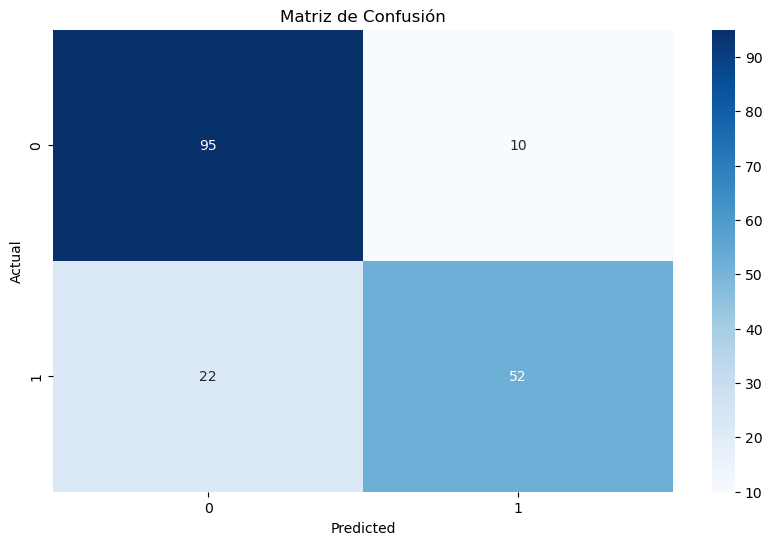

In [14]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Matriz de Confusión')
plt.show()